
--- DATA HEAD ---
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId  

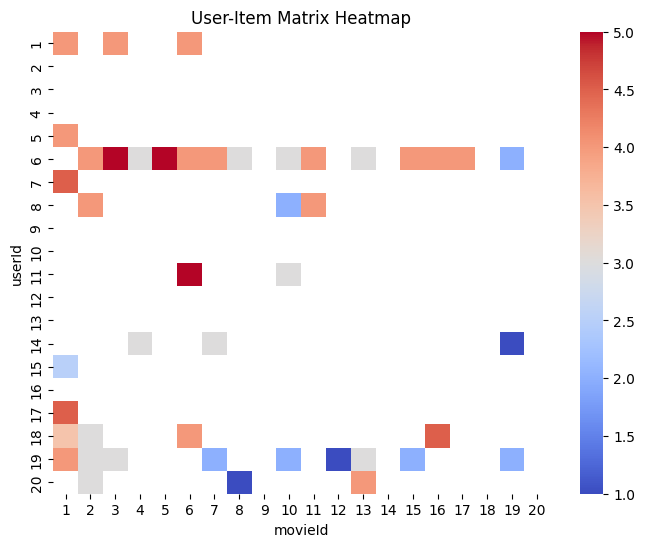

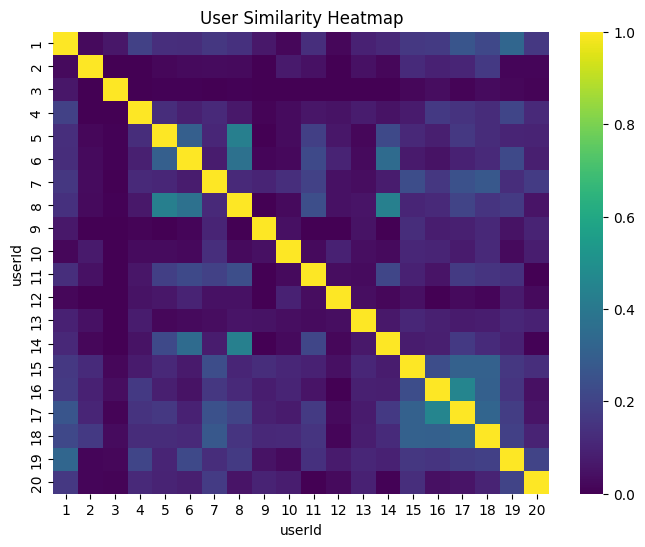

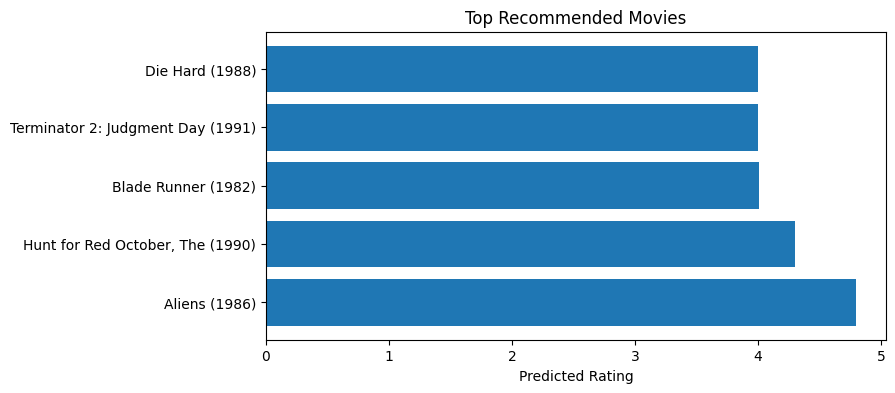


Name: Yamini M
Reg No: 24BAD131


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

print("\n--- DATA HEAD ---")
print(data.head())

print("\n--- DATA INFO ---")
print(data.info())

print("\n--- MISSING VALUES ---")
print(data.isnull().sum())

print("\nUsers:", data.userId.nunique())
print("Movies:", data.movieId.nunique())

user_item_matrix = data.pivot(index="userId", columns="movieId", values="rating")

user_item_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

print("\n--- Similar Users for User 1 ---")
print(get_similar_users(1))

def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, 5)

    sim_scores = similar_users.values
    sim_users = similar_users.index

    weighted_sum = user_item_filled.loc[sim_users].T.dot(sim_scores)
    sim_total = np.sum(sim_scores)

    predictions = weighted_sum / sim_total
    return predictions

def recommend_movies(user_id, n=5):
    predictions = predict_ratings(user_id)

    watched = user_item_matrix.loc[user_id].dropna().index
    recommendations = predictions.drop(watched)

    top = recommendations.sort_values(ascending=False).head(n)

    result = pd.merge(top.reset_index(),
                      movies,
                      on="movieId")[["title", 0]]

    result.columns = ["Movie", "Predicted Rating"]
    return result

print("\n--- Top Recommendations for User 1 ---")
rec = recommend_movies(1)
print(rec)

train, test = train_test_split(data, test_size=0.2, random_state=42)

train_matrix = train.pivot(index="userId", columns="movieId", values="rating")
test_matrix = test.pivot(index="userId", columns="movieId", values="rating")

train_matrix = train_matrix.fillna(0)
test_matrix = test_matrix.fillna(0)

train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=1, fill_value=0)
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=0, fill_value=0)

similarity = cosine_similarity(train_matrix)

pred = similarity.dot(train_matrix) / np.array([np.abs(similarity).sum(axis=1)]).T

pred_df = pd.DataFrame(pred, index=train_matrix.index, columns=train_matrix.columns)

mask = test_matrix > 0

pred_flat = pred_df[mask].values.flatten()
test_flat = test_matrix[mask].values.flatten()

valid = test_flat > 0
pred_flat = pred_flat[valid]
test_flat = test_flat[valid]

rmse = np.sqrt(mean_squared_error(test_flat, pred_flat))
mae = mean_absolute_error(test_flat, pred_flat)

print("\n--- MODEL EVALUATION ---")
print("RMSE:", rmse)
print("MAE:", mae)

sparsity = 1 - (user_item_matrix.count().sum() /
               (user_item_matrix.shape[0] * user_item_matrix.shape[1]))

print("\n--- ANALYSIS ---")
print("Sparsity of matrix:", sparsity)

plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("User Similarity Heatmap")
plt.show()

plt.figure(figsize=(8,4))
plt.barh(rec["Movie"], rec["Predicted Rating"])
plt.title("Top Recommended Movies")
plt.xlabel("Predicted Rating")
plt.show()


print("\nName: Yamini M")
print("Reg No: 24BAD131")


--- Similar Items for Movie ID 1 ---
movieId
3114    0.572601
480     0.565637
780     0.564262
260     0.557388
356     0.547096
Name: 1, dtype: float64

--- Recommendations for User 1 ---
                             Movie       Score
0  Ferris Bueller's Day Off (1986)  352.684010
1                  Die Hard (1988)  330.949884
2       Breakfast Club, The (1985)  328.180507
3        Fifth Element, The (1997)  326.437374
4                    Aliens (1986)  323.117648

--- MODEL EVALUATION ---
RMSE: 3.3793030095011862
Precision@K: 0.0

--- Popular Items ---
title
Forrest Gump (1994)                 329
Shawshank Redemption, The (1994)    317
Pulp Fiction (1994)                 307
Silence of the Lambs, The (1991)    279
Matrix, The (1999)                  278
Name: rating, dtype: int64

--- Niche Items ---
title
12 Chairs (1971)                                                                            1
12 Chairs (1976)                                                                  

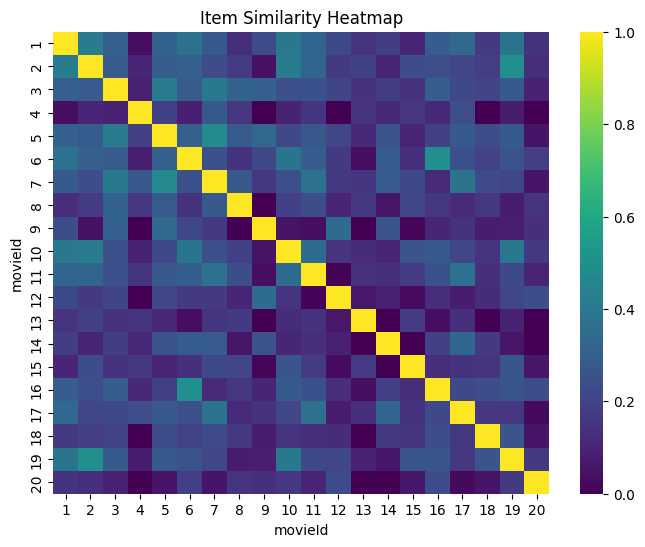

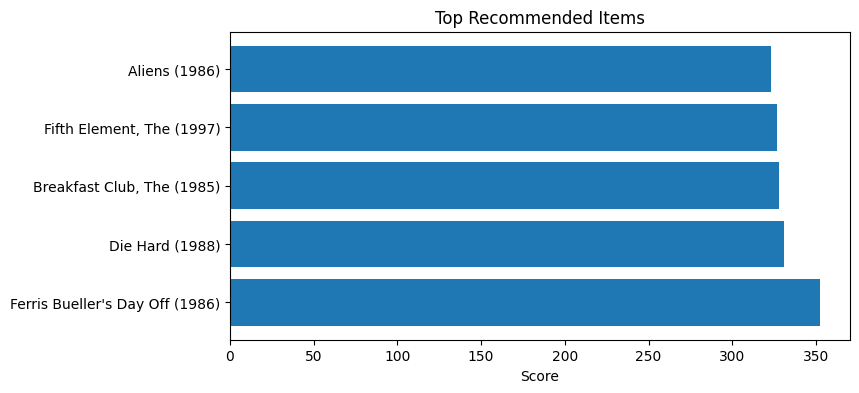

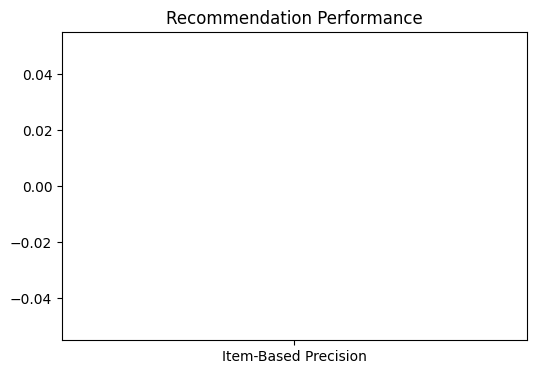


Name: Yamini M
Reg No: 24BAD131


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

# Create Item-User Matrix
item_user_matrix = data.pivot(index="movieId", columns="userId", values="rating")
item_user_filled = item_user_matrix.fillna(0)

# Compute similarity
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

# -------------------------------
# Similar items
# -------------------------------
def get_similar_items(movie_id, n=5):
    return item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]

print("\n--- Similar Items for Movie ID 1 ---")
print(get_similar_items(1))

# -------------------------------
# Recommendation function
# -------------------------------
def recommend_items(user_id, n=5):
    user_ratings = item_user_matrix[user_id].dropna()
    scores = pd.Series(dtype=np.float64)

    for movie, rating in user_ratings.items():
        similar_items = item_similarity_df[movie]
        scores = scores.add(similar_items * rating, fill_value=0)

    watched = user_ratings.index
    scores = scores.drop(watched)

    top_items = scores.sort_values(ascending=False).head(n)

    result = pd.merge(top_items.reset_index(),
                      movies,
                      on="movieId")[["title", 0]]

    result.columns = ["Movie", "Score"]
    return result

print("\n--- Recommendations for User 1 ---")
rec_items = recommend_items(1)
print(rec_items)

# -------------------------------
# Train-Test Split
# -------------------------------
train, test = train_test_split(data, test_size=0.2, random_state=42)

train_matrix = train.pivot(index="movieId", columns="userId", values="rating").fillna(0)
test_matrix = test.pivot(index="movieId", columns="userId", values="rating").fillna(0)

# Align matrices
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=1, fill_value=0)
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=0, fill_value=0)

# -------------------------------
# Prediction (FIXED)
# -------------------------------
similarity = cosine_similarity(train_matrix)

# Avoid division by zero
sim_sum = np.abs(similarity).sum(axis=1)
sim_sum[sim_sum == 0] = 1   # FIX

pred = similarity.dot(train_matrix) / sim_sum[:, None]

# Replace NaN safely
pred = np.nan_to_num(pred)

pred_df = pd.DataFrame(pred, index=train_matrix.index, columns=train_matrix.columns)

# -------------------------------
# Evaluation
# -------------------------------
mask = test_matrix > 0

pred_flat = pred_df[mask].values.flatten()
test_flat = test_matrix[mask].values.flatten()

# Remove any remaining invalid values
valid = ~np.isnan(pred_flat) & ~np.isnan(test_flat)
pred_flat = pred_flat[valid]
test_flat = test_flat[valid]

rmse = np.sqrt(mean_squared_error(test_flat, pred_flat))

# -------------------------------
# Precision@K
# -------------------------------
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)["Movie"]
    actual = data[data["userId"] == user_id] \
             .sort_values(by="rating", ascending=False)["title"].head(k)

    relevant = set(recommended).intersection(set(actual))
    return len(relevant) / k

precision = precision_at_k(1)

print("\n--- MODEL EVALUATION ---")
print("RMSE:", rmse)
print("Precision@K:", precision)

# -------------------------------
# Analysis
# -------------------------------
popular_items = data.groupby("title")["rating"].count().sort_values(ascending=False).head(5)
niche_items = data.groupby("title")["rating"].count().sort_values().head(5)

print("\n--- Popular Items ---")
print(popular_items)

print("\n--- Niche Items ---")
print(niche_items)

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("Item Similarity Heatmap")
plt.show()

plt.figure(figsize=(8,4))
plt.barh(rec_items["Movie"], rec_items["Score"])
plt.title("Top Recommended Items")
plt.xlabel("Score")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Item-Based Precision"], [precision])
plt.title("Recommendation Performance")
plt.show()

# -------------------------------
# Student Details
# -------------------------------
print("\nName: Yamini M")
print("Reg No: 24BAD131")